In [21]:
import os
import json
import csv
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

# Seed
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
ARTIFACTS_DIR = "artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

Device: cpu


In [22]:
DATASET_NAME = "EMNIST"
BATCH_SIZE = 128
VAL_RATIO = 0.2

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download datasets
full_train = torchvision.datasets.EMNIST(root="./data", split="balanced", train=True,
                                          download=True, transform=transform)
test_dataset = torchvision.datasets.EMNIST(root="./data", split="balanced", train=False,
                                            download=True, transform=transform)

# Reproducible train/val split
n_val = int(len(full_train) * VAL_RATIO)
n_train = len(full_train) - n_val
train_dataset, val_dataset = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")

# Sanity check
x_batch, y_batch = next(iter(train_loader))
print(f"x.shape: {x_batch.shape}, y.shape: {y_batch.shape}")
print(f"x range: [{x_batch.min():.2f}, {x_batch.max():.2f}]")
print(f"Num classes: {len(full_train.classes)}")

NUM_CLASSES = len(full_train.classes)
INPUT_SIZE = 28 * 28

Train size: 90240, Val size: 22560, Test size: 18800
x.shape: torch.Size([128, 1, 28, 28]), y.shape: torch.Size([128])
x range: [-0.42, 2.82]
Num classes: 47


In [18]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes,
                 dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        layers = [nn.Flatten()]
        in_features = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0.0:
                layers.append(nn.Dropout(p=dropout_p))
            in_features = h
        layers.append(nn.Linear(in_features, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total


def run_experiment(model, train_loader, val_loader, criterion,
                   optimizer, epochs, device, patience=None):
    """Train model, optionally with early stopping.
    
    Returns:
        history        : dict with per-epoch train/val loss and accuracy
        best_val_loss  : val_loss of the checkpoint saved to the model
        best_val_acc   : val_acc  of the same checkpoint (consistent pair)
    """
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    best_val_acc  = 0.0
    best_state    = None
    no_improve    = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:3d} | tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} "
              f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        # Checkpoint: save best weights together with the matching accuracy
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc  = val_acc   # same epoch — metrics are consistent
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if patience is not None and no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    # Restore the best checkpoint regardless of early stopping
    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_loss, best_val_acc


print("Functions defined.")

Functions defined.


In [4]:
HIDDEN_SIZES = [512, 256, 128]
EPOCHS_PART_A = 15
LR_BASE = 1e-3
criterion = nn.CrossEntropyLoss()

all_histories = {}
results = []  # will hold rows for runs.csv

In [5]:
torch.manual_seed(SEED)
model_e1 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES, dropout_p=0.0, use_batchnorm=False).to(device)
opt_e1 = optim.Adam(model_e1.parameters(), lr=LR_BASE)

print("=== E1: Base ===")
hist_e1 = run_experiment(model_e1, train_loader, val_loader, criterion, opt_e1, EPOCHS_PART_A, device)
all_histories["E1"] = hist_e1

best_val_acc_e1 = max(hist_e1["val_acc"])
best_val_loss_e1 = min(hist_e1["val_loss"])
print(f"E1 best val_acc: {best_val_acc_e1:.4f}")

results.append({
    "experiment_id": "E1", "dataset": DATASET_NAME, "seed": SEED,
    "model_summary": "512-256-128/ReLU/no_dropout/no_BN",
    "optimizer": "Adam", "lr": LR_BASE, "momentum": "", "weight_decay": 0,
    "epochs_trained": EPOCHS_PART_A,
    "best_val_accuracy": round(best_val_acc_e1, 4),
    "best_val_loss": round(best_val_loss_e1, 4)
})

=== E1: Base ===
Epoch   1 | tr_loss=0.9807 tr_acc=0.7023 | val_loss=0.6287 val_acc=0.7965
Epoch   2 | tr_loss=0.5366 tr_acc=0.8187 | val_loss=0.5527 val_acc=0.8177
Epoch   3 | tr_loss=0.4487 tr_acc=0.8435 | val_loss=0.4790 val_acc=0.8373
Epoch   4 | tr_loss=0.3913 tr_acc=0.8593 | val_loss=0.4803 val_acc=0.8427
Epoch   5 | tr_loss=0.3506 tr_acc=0.8707 | val_loss=0.4787 val_acc=0.8407
Epoch   6 | tr_loss=0.3186 tr_acc=0.8783 | val_loss=0.4851 val_acc=0.8407
Epoch   7 | tr_loss=0.2949 tr_acc=0.8866 | val_loss=0.4808 val_acc=0.8449
Epoch   8 | tr_loss=0.2743 tr_acc=0.8924 | val_loss=0.5142 val_acc=0.8397
Epoch   9 | tr_loss=0.2549 tr_acc=0.8992 | val_loss=0.5135 val_acc=0.8474
Epoch  10 | tr_loss=0.2401 tr_acc=0.9040 | val_loss=0.5294 val_acc=0.8456
Epoch  11 | tr_loss=0.2270 tr_acc=0.9083 | val_loss=0.5511 val_acc=0.8434
Epoch  12 | tr_loss=0.2166 tr_acc=0.9111 | val_loss=0.5762 val_acc=0.8437
Epoch  13 | tr_loss=0.2109 tr_acc=0.9136 | val_loss=0.5888 val_acc=0.8449
Epoch  14 | tr_loss=0

In [6]:
torch.manual_seed(SEED)
model_e2 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES, dropout_p=0.3, use_batchnorm=False).to(device)
opt_e2 = optim.Adam(model_e2.parameters(), lr=LR_BASE)

print("=== E2: Dropout p=0.3 ===")
hist_e2 = run_experiment(model_e2, train_loader, val_loader, criterion, opt_e2, EPOCHS_PART_A, device)
all_histories["E2"] = hist_e2

best_val_acc_e2 = max(hist_e2["val_acc"])
best_val_loss_e2 = min(hist_e2["val_loss"])
print(f"E2 best val_acc: {best_val_acc_e2:.4f}")

results.append({
    "experiment_id": "E2", "dataset": DATASET_NAME, "seed": SEED,
    "model_summary": "512-256-128/ReLU/dropout=0.3/no_BN",
    "optimizer": "Adam", "lr": LR_BASE, "momentum": "", "weight_decay": 0,
    "epochs_trained": EPOCHS_PART_A,
    "best_val_accuracy": round(best_val_acc_e2, 4),
    "best_val_loss": round(best_val_loss_e2, 4)
})

=== E2: Dropout p=0.3 ===
Epoch   1 | tr_loss=1.3368 tr_acc=0.6031 | val_loss=0.6886 val_acc=0.7772
Epoch   2 | tr_loss=0.7986 tr_acc=0.7459 | val_loss=0.5705 val_acc=0.8127
Epoch   3 | tr_loss=0.6978 tr_acc=0.7740 | val_loss=0.5248 val_acc=0.8248
Epoch   4 | tr_loss=0.6400 tr_acc=0.7887 | val_loss=0.5007 val_acc=0.8330
Epoch   5 | tr_loss=0.6073 tr_acc=0.7986 | val_loss=0.4828 val_acc=0.8386
Epoch   6 | tr_loss=0.5749 tr_acc=0.8078 | val_loss=0.4697 val_acc=0.8430
Epoch   7 | tr_loss=0.5615 tr_acc=0.8104 | val_loss=0.4693 val_acc=0.8438
Epoch   8 | tr_loss=0.5411 tr_acc=0.8172 | val_loss=0.4552 val_acc=0.8461
Epoch   9 | tr_loss=0.5301 tr_acc=0.8185 | val_loss=0.4605 val_acc=0.8474
Epoch  10 | tr_loss=0.5230 tr_acc=0.8221 | val_loss=0.4554 val_acc=0.8422
Epoch  11 | tr_loss=0.5081 tr_acc=0.8242 | val_loss=0.4483 val_acc=0.8468
Epoch  12 | tr_loss=0.4979 tr_acc=0.8278 | val_loss=0.4432 val_acc=0.8540
Epoch  13 | tr_loss=0.4914 tr_acc=0.8307 | val_loss=0.4384 val_acc=0.8508
Epoch  14 | 

In [7]:
torch.manual_seed(SEED)
model_e3 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES, dropout_p=0.0, use_batchnorm=True).to(device)
opt_e3 = optim.Adam(model_e3.parameters(), lr=LR_BASE)

print("=== E3: BatchNorm ===")
hist_e3 = run_experiment(model_e3, train_loader, val_loader, criterion, opt_e3, EPOCHS_PART_A, device)
all_histories["E3"] = hist_e3

best_val_acc_e3 = max(hist_e3["val_acc"])
best_val_loss_e3 = min(hist_e3["val_loss"])
print(f"E3 best val_acc: {best_val_acc_e3:.4f}")

results.append({
    "experiment_id": "E3", "dataset": DATASET_NAME, "seed": SEED,
    "model_summary": "512-256-128/ReLU/no_dropout/BN",
    "optimizer": "Adam", "lr": LR_BASE, "momentum": "", "weight_decay": 0,
    "epochs_trained": EPOCHS_PART_A,
    "best_val_accuracy": round(best_val_acc_e3, 4),
    "best_val_loss": round(best_val_loss_e3, 4)
})

=== E3: BatchNorm ===
Epoch   1 | tr_loss=0.8925 tr_acc=0.7483 | val_loss=0.5488 val_acc=0.8187
Epoch   2 | tr_loss=0.4855 tr_acc=0.8339 | val_loss=0.4848 val_acc=0.8373
Epoch   3 | tr_loss=0.4121 tr_acc=0.8546 | val_loss=0.4427 val_acc=0.8487
Epoch   4 | tr_loss=0.3630 tr_acc=0.8687 | val_loss=0.4405 val_acc=0.8504
Epoch   5 | tr_loss=0.3318 tr_acc=0.8768 | val_loss=0.4415 val_acc=0.8496
Epoch   6 | tr_loss=0.3040 tr_acc=0.8845 | val_loss=0.4419 val_acc=0.8489
Epoch   7 | tr_loss=0.2816 tr_acc=0.8919 | val_loss=0.4324 val_acc=0.8532
Epoch   8 | tr_loss=0.2601 tr_acc=0.8991 | val_loss=0.4435 val_acc=0.8566
Epoch   9 | tr_loss=0.2458 tr_acc=0.9031 | val_loss=0.4569 val_acc=0.8525
Epoch  10 | tr_loss=0.2320 tr_acc=0.9069 | val_loss=0.4589 val_acc=0.8550
Epoch  11 | tr_loss=0.2171 tr_acc=0.9128 | val_loss=0.4674 val_acc=0.8508
Epoch  12 | tr_loss=0.2077 tr_acc=0.9149 | val_loss=0.4773 val_acc=0.8505
Epoch  13 | tr_loss=0.1945 tr_acc=0.9204 | val_loss=0.4840 val_acc=0.8550
Epoch  14 | tr_l

In [8]:
# Pick best from E2/E3
if best_val_acc_e2 >= best_val_acc_e3:
    best_config = dict(dropout_p=0.3, use_batchnorm=False, config_name="Dropout")
    print(f"Best config: E2 (Dropout), val_acc={best_val_acc_e2:.4f}")
else:
    best_config = dict(dropout_p=0.0, use_batchnorm=True, config_name="BatchNorm")
    print(f"Best config: E3 (BatchNorm), val_acc={best_val_acc_e3:.4f}")

torch.manual_seed(SEED)
model_e4 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
               dropout_p=best_config["dropout_p"],
               use_batchnorm=best_config["use_batchnorm"]).to(device)
opt_e4 = optim.Adam(model_e4.parameters(), lr=LR_BASE)

print("=== E4: Best config + EarlyStopping (patience=5) ===")
hist_e4 = run_experiment(model_e4, train_loader, val_loader, criterion, opt_e4,
                         epochs=30, device=device, patience=5)
all_histories["E4"] = hist_e4

best_val_acc_e4 = max(hist_e4["val_acc"])
best_val_loss_e4 = min(hist_e4["val_loss"])
epochs_trained_e4 = len(hist_e4["val_acc"])
print(f"E4 best val_acc: {best_val_acc_e4:.4f}, epochs: {epochs_trained_e4}")

results.append({
    "experiment_id": "E4", "dataset": DATASET_NAME, "seed": SEED,
    "model_summary": f"512-256-128/ReLU/{best_config['config_name']}/EarlyStopping",
    "optimizer": "Adam", "lr": LR_BASE, "momentum": "", "weight_decay": 0,
    "epochs_trained": epochs_trained_e4,
    "best_val_accuracy": round(best_val_acc_e4, 4),
    "best_val_loss": round(best_val_loss_e4, 4)
})

Best config: E3 (BatchNorm), val_acc=0.8566
=== E4: Best config + EarlyStopping (patience=5) ===
Epoch   1 | tr_loss=0.8925 tr_acc=0.7483 | val_loss=0.5488 val_acc=0.8187
Epoch   2 | tr_loss=0.4855 tr_acc=0.8339 | val_loss=0.4848 val_acc=0.8373
Epoch   3 | tr_loss=0.4121 tr_acc=0.8546 | val_loss=0.4427 val_acc=0.8487
Epoch   4 | tr_loss=0.3630 tr_acc=0.8687 | val_loss=0.4405 val_acc=0.8504
Epoch   5 | tr_loss=0.3318 tr_acc=0.8768 | val_loss=0.4415 val_acc=0.8496
Epoch   6 | tr_loss=0.3040 tr_acc=0.8845 | val_loss=0.4419 val_acc=0.8489
Epoch   7 | tr_loss=0.2816 tr_acc=0.8919 | val_loss=0.4324 val_acc=0.8532
Epoch   8 | tr_loss=0.2601 tr_acc=0.8991 | val_loss=0.4435 val_acc=0.8566
Epoch   9 | tr_loss=0.2458 tr_acc=0.9031 | val_loss=0.4569 val_acc=0.8525
Epoch  10 | tr_loss=0.2320 tr_acc=0.9069 | val_loss=0.4589 val_acc=0.8550
Epoch  11 | tr_loss=0.2171 tr_acc=0.9128 | val_loss=0.4674 val_acc=0.8508
Epoch  12 | tr_loss=0.2077 tr_acc=0.9149 | val_loss=0.4773 val_acc=0.8505
  Early stoppin

In [9]:
# Save best model
torch.save(model_e4.state_dict(), os.path.join(ARTIFACTS_DIR, "best_model.pt"))
print("Saved best_model.pt")

# Save best config
best_cfg_dict = {
    "dataset": DATASET_NAME,
    "seed": SEED,
    "input_size": INPUT_SIZE,
    "hidden_sizes": HIDDEN_SIZES,
    "num_classes": NUM_CLASSES,
    "dropout_p": best_config["dropout_p"],
    "use_batchnorm": best_config["use_batchnorm"],
    "optimizer": "Adam",
    "lr": LR_BASE,
    "weight_decay": 0,
    "early_stopping_patience": 5
}
with open(os.path.join(ARTIFACTS_DIR, "best_config.json"), "w") as f:
    json.dump(best_cfg_dict, f, indent=2)
print("Saved best_config.json")

Saved best_model.pt
Saved best_config.json


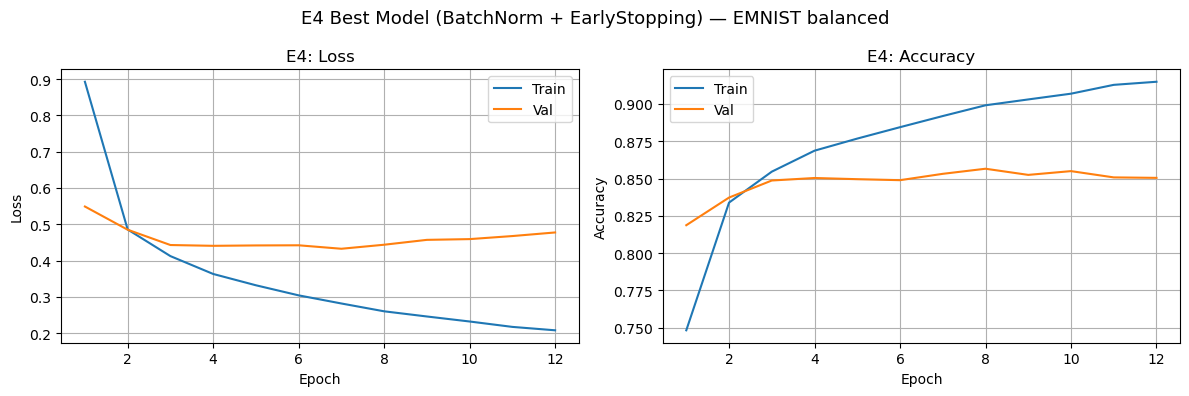

Saved curves_best.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(hist_e4["train_loss"]) + 1)

axes[0].plot(epochs_range, hist_e4["train_loss"], label="Train")
axes[0].plot(epochs_range, hist_e4["val_loss"], label="Val")
axes[0].set_title("E4: Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, hist_e4["train_acc"], label="Train")
axes[1].plot(epochs_range, hist_e4["val_acc"], label="Val")
axes[1].set_title("E4: Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

fig.suptitle(f"E4 Best Model ({best_config['config_name']} + EarlyStopping) — EMNIST balanced", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "curves_best.png"), dpi=120)
plt.show()
print("Saved curves_best.png")

In [11]:
torch.manual_seed(SEED)
model_o1 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
               dropout_p=best_config["dropout_p"],
               use_batchnorm=best_config["use_batchnorm"]).to(device)
opt_o1 = optim.Adam(model_o1.parameters(), lr=1e-1)

print("=== O1: LR too large (1e-1) ===")
hist_o1 = run_experiment(model_o1, train_loader, val_loader, criterion, opt_o1, epochs=7, device=device)
all_histories["O1"] = hist_o1

best_val_acc_o1 = max(hist_o1["val_acc"])
results.append({
    "experiment_id": "O1", "dataset": DATASET_NAME, "seed": SEED,
    "model_summary": f"512-256-128/ReLU/{best_config['config_name']}",
    "optimizer": "Adam", "lr": 1e-1, "momentum": "", "weight_decay": 0,
    "epochs_trained": 7,
    "best_val_accuracy": round(best_val_acc_o1, 4),
    "best_val_loss": round(min(hist_o1["val_loss"]), 4)
})

=== O1: LR too large (1e-1) ===
Epoch   1 | tr_loss=1.0863 tr_acc=0.6691 | val_loss=0.7866 val_acc=0.7532
Epoch   2 | tr_loss=0.7442 tr_acc=0.7603 | val_loss=0.6939 val_acc=0.7717
Epoch   3 | tr_loss=0.6498 tr_acc=0.7873 | val_loss=0.6305 val_acc=0.7885
Epoch   4 | tr_loss=0.6072 tr_acc=0.7989 | val_loss=0.6009 val_acc=0.8106
Epoch   5 | tr_loss=0.5648 tr_acc=0.8107 | val_loss=0.5732 val_acc=0.8089
Epoch   6 | tr_loss=0.5384 tr_acc=0.8182 | val_loss=0.5899 val_acc=0.8073
Epoch   7 | tr_loss=0.5167 tr_acc=0.8253 | val_loss=0.5844 val_acc=0.8178


In [12]:
torch.manual_seed(SEED)
model_o2 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
               dropout_p=best_config["dropout_p"],
               use_batchnorm=best_config["use_batchnorm"]).to(device)
opt_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)

print("=== O2: LR too small (1e-5) ===")
hist_o2 = run_experiment(model_o2, train_loader, val_loader, criterion, opt_o2, epochs=7, device=device)
all_histories["O2"] = hist_o2

best_val_acc_o2 = max(hist_o2["val_acc"])
results.append({
    "experiment_id": "O2", "dataset": DATASET_NAME, "seed": SEED,
    "model_summary": f"512-256-128/ReLU/{best_config['config_name']}",
    "optimizer": "Adam", "lr": 1e-5, "momentum": "", "weight_decay": 0,
    "epochs_trained": 7,
    "best_val_accuracy": round(best_val_acc_o2, 4),
    "best_val_loss": round(min(hist_o2["val_loss"]), 4)
})

=== O2: LR too small (1e-5) ===
Epoch   1 | tr_loss=3.3254 tr_acc=0.2541 | val_loss=2.9099 val_acc=0.4461
Epoch   2 | tr_loss=2.6837 tr_acc=0.5124 | val_loss=2.4786 val_acc=0.5657
Epoch   3 | tr_loss=2.3230 tr_acc=0.5961 | val_loss=2.1731 val_acc=0.6259
Epoch   4 | tr_loss=2.0474 tr_acc=0.6431 | val_loss=1.9253 val_acc=0.6604
Epoch   5 | tr_loss=1.8219 tr_acc=0.6736 | val_loss=1.7183 val_acc=0.6844
Epoch   6 | tr_loss=1.6330 tr_acc=0.6971 | val_loss=1.5459 val_acc=0.7050
Epoch   7 | tr_loss=1.4740 tr_acc=0.7174 | val_loss=1.4011 val_acc=0.7239


In [13]:
torch.manual_seed(SEED)
model_o3 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
               dropout_p=best_config["dropout_p"],
               use_batchnorm=best_config["use_batchnorm"]).to(device)
opt_o3 = optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)

print("=== O3: SGD + momentum=0.9 + weight_decay=1e-4 ===")
hist_o3 = run_experiment(model_o3, train_loader, val_loader, criterion, opt_o3, epochs=12, device=device)
all_histories["O3"] = hist_o3

best_val_acc_o3 = max(hist_o3["val_acc"])
results.append({
    "experiment_id": "O3", "dataset": DATASET_NAME, "seed": SEED,
    "model_summary": f"512-256-128/ReLU/{best_config['config_name']}",
    "optimizer": "SGD", "lr": 1e-2, "momentum": 0.9, "weight_decay": 1e-4,
    "epochs_trained": 12,
    "best_val_accuracy": round(best_val_acc_o3, 4),
    "best_val_loss": round(min(hist_o3["val_loss"]), 4)
})

=== O3: SGD + momentum=0.9 + weight_decay=1e-4 ===
Epoch   1 | tr_loss=1.0087 tr_acc=0.7246 | val_loss=0.5908 val_acc=0.8089
Epoch   2 | tr_loss=0.5155 tr_acc=0.8284 | val_loss=0.4998 val_acc=0.8348
Epoch   3 | tr_loss=0.4306 tr_acc=0.8506 | val_loss=0.4681 val_acc=0.8398
Epoch   4 | tr_loss=0.3771 tr_acc=0.8674 | val_loss=0.4576 val_acc=0.8442
Epoch   5 | tr_loss=0.3419 tr_acc=0.8761 | val_loss=0.4595 val_acc=0.8454
Epoch   6 | tr_loss=0.3146 tr_acc=0.8845 | val_loss=0.4569 val_acc=0.8434
Epoch   7 | tr_loss=0.2892 tr_acc=0.8920 | val_loss=0.4379 val_acc=0.8527
Epoch   8 | tr_loss=0.2693 tr_acc=0.8970 | val_loss=0.4473 val_acc=0.8508
Epoch   9 | tr_loss=0.2526 tr_acc=0.9033 | val_loss=0.4496 val_acc=0.8518
Epoch  10 | tr_loss=0.2372 tr_acc=0.9075 | val_loss=0.4551 val_acc=0.8490
Epoch  11 | tr_loss=0.2218 tr_acc=0.9138 | val_loss=0.4599 val_acc=0.8482
Epoch  12 | tr_loss=0.2109 tr_acc=0.9164 | val_loss=0.4718 val_acc=0.8488


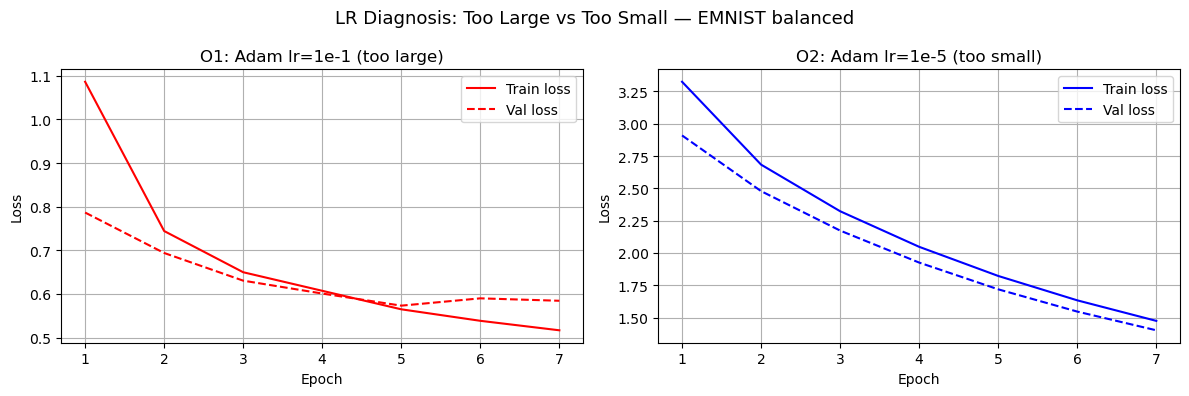

Saved curves_lr_extremes.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, exp_id, hist, lr_label, color in [
    (axes[0], "O1", hist_o1, "lr=1e-1 (too large)", "red"),
    (axes[1], "O2", hist_o2, "lr=1e-5 (too small)", "blue")
]:
    ep = range(1, len(hist["train_loss"]) + 1)
    ax.plot(ep, hist["train_loss"], label="Train loss", color=color, linestyle="-")
    ax.plot(ep, hist["val_loss"], label="Val loss", color=color, linestyle="--")
    ax.set_title(f"{exp_id}: Adam {lr_label}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)

fig.suptitle("LR Diagnosis: Too Large vs Too Small — EMNIST balanced", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "curves_lr_extremes.png"), dpi=120)
plt.show()
print("Saved curves_lr_extremes.png")

In [15]:
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"=== Final Test Evaluation (E4) ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

=== Final Test Evaluation (E4) ===
Test Loss: 0.4633
Test Accuracy: 0.8493


In [16]:
fieldnames = [
    "experiment_id", "dataset", "seed", "model_summary",
    "optimizer", "lr", "momentum", "weight_decay",
    "epochs_trained", "best_val_accuracy", "best_val_loss"
]

csv_path = os.path.join(ARTIFACTS_DIR, "runs.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)

print(f"Saved runs.csv with {len(results)} rows:")
for r in results:
    print(f"  {r['experiment_id']}: val_acc={r['best_val_accuracy']}")

Saved runs.csv with 7 rows:
  E1: val_acc=0.8474
  E2: val_acc=0.854
  E3: val_acc=0.8566
  E4: val_acc=0.8566
  O1: val_acc=0.8178
  O2: val_acc=0.7239
  O3: val_acc=0.8527


In [17]:
print(f"{'ID':<6} {'Optimizer':<6} {'LR':<8} {'Momentum':<10} {'WD':<8} {'Epochs':<8} {'Val Acc':<10} {'Val Loss'}")
print("-" * 72)
for r in results:
    print(f"{r['experiment_id']:<6} {r['optimizer']:<6} {r['lr']:<8} {str(r['momentum']):<10} "
          f"{r['weight_decay']:<8} {r['epochs_trained']:<8} {r['best_val_accuracy']:<10} {r['best_val_loss']}")

print(f"\n>>> Test accuracy (E4 best model): {test_acc:.4f}")

ID     Optimizer LR       Momentum   WD       Epochs   Val Acc    Val Loss
------------------------------------------------------------------------
E1     Adam   0.001               0        15       0.8474     0.4787
E2     Adam   0.001               0        15       0.854      0.4384
E3     Adam   0.001               0        15       0.8566     0.4324
E4     Adam   0.001               0        12       0.8566     0.4324
O1     Adam   0.1                 0        7        0.8178     0.5732
O2     Adam   1e-05               0        7        0.7239     1.4011
O3     SGD    0.01     0.9        0.0001   12       0.8527     0.4379

>>> Test accuracy (E4 best model): 0.8493
